In [1]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

Método de Crank-Nicholson

In [4]:
def Mat_AB(x,r):
    N = len(x)-2
    A , B = np.zeros((N,N)) , np.zeros((N,N))
    d_A , d_B = 2*(1+r) , 2*(1-r)
    for i in range(N-1):
        A[i,i] , B[i,i] = d_A , d_B
        A[i,i+1] , B[i,i+1] = -r , r
        A[i+1,i] , B[i+1,i] = -r , r
    A[-1,-1] , B[-1,-1] = d_A , d_B
    return A , B

def Met_CN(x,t,Psi0,D=0.5):
    r = (D*(t[1]-t[0]))/((x[1]-x[0])**2)
    sol = np.zeros( (len(x),len(t)) )
    sol[:,0] = Psi0
    #print('Valor r=',r)
    if r < 1:
        A , B = Mat_AB(x,r)
        A_inv = la.inv(A)
        M_evol = np.dot(A_inv,B)
        for i in range(len(t)-1):
            # Solo evolucionar los puntos interiores
            sol[1:-1,i+1] = np.dot(M_evol,sol[1:-1,i])
    else:
        print('No hay convergencia')
    return sol

Valor r= 0.9070351758793972


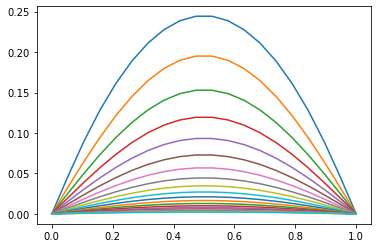

In [3]:
x , t = np.linspace(0,1,20) , np.linspace(0,1,200)
P0 = -x*(x-1)
sol_Psi = Met_CN(x,t,P0)
for i in range(1,200,10):
    plt.plot(x,sol_Psi[:,i])
plt.show()

In [5]:
%%timeit
sol_Psi = Met_CN(x,t,P0)

512 µs ± 101 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


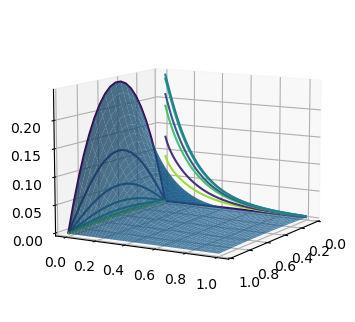

In [45]:
XX,TT = np.meshgrid(x,t)
fig = plt.figure(dpi=100)
ejes = fig.add_subplot(111,projection='3d')
ejes.set_xlim3d([x[0],x[-1]]),ejes.set_xlim3d([t[0],t[-1]])
ejes.set_zlim3d([0,max(P0)])
ejes.plot_surface(XX,TT,sol_Psi.transpose(),alpha=0.75)
ejes.contour(XX,TT,sol_Psi.transpose(),zdir='x',offset=0)
ejes.contour(XX,TT,sol_Psi.transpose(),zdir='y',offset=0)
ejes.view_init(10,30)

In [34]:
fig , ejes = plt.subplots(1,1)
ejes.set_xlim([x[0],x[-1]]),ejes.set_ylim([0,max(P0)])
ejes.set_aspect('equal')

Psi_i, = ejes.plot([],[],color='red')

def cuadro(n):
    Psi_i.set_data(x,sol_Psi[:,n])
    return Psi_i,

animacion = FuncAnimation(fig,cuadro,frames=len(t),
                          interval = 40,blit=True)

plt.close()
HTML(animacion.to_html5_video()) # Usar esta linea si tengo compresor de video
#HTML(animacion.to_jshtml()) # Usar esta linea si NO tengo compresor de video

In [67]:
def P0_barritas(x,T_max=1):
    P0 = np.zeros_like(x)
    for i in range(len(x)):
        if 0.3 < x[i] < 0.6:
            P0[i] = T_max
    return P0

In [74]:
x , t = np.linspace(0,1,50) , np.linspace(0,1,1500)
P0_T10 = P0_barritas(x,10)
sol_Psi_T10 = Met_CN(x,t,P0_T10)
P0_T1 = P0_barritas(x,1)
sol_Psi_T1 = Met_CN(x,t,P0_T1)
P0_T025 = P0_barritas(x,0.25)
sol_Psi_T025 = Met_CN(x,t,P0_T025)
P0_Tm1 = P0_barritas(x,-1)
sol_Psi_Tm1 = Met_CN(x,t,P0_Tm1)

Valor r= 0.8008672448298867
Valor r= 0.8008672448298867
Valor r= 0.8008672448298867
Valor r= 0.8008672448298867


In [76]:
fig , ejes = plt.subplots(1,1)
ejes.set_xlim([x[0],x[-1]]),ejes.set_ylim([-1.1,10.1])

Psi_i_T10, = ejes.plot([],[],color='tab:red',label=r'$T_i$ = 10')
Psi_i_T1, = ejes.plot([],[],color='tab:blue',label=r'$T_i$ = 1')
Psi_i_T025, = ejes.plot([],[],color='orange',label=r'$T_i$ = 0.25')
Psi_i_Tm1, = ejes.plot([],[],color='purple',label=r'$T_i$ = -1')
ejes.legend()

def cuadro(n):
    Psi_i_T10.set_data(x,sol_Psi_T10[:,n])
    Psi_i_T1.set_data(x,sol_Psi_T1[:,n])
    Psi_i_T025.set_data(x,sol_Psi_T025[:,n])
    Psi_i_Tm1.set_data(x,sol_Psi_Tm1[:,n])
    return Psi_i_T10,Psi_i_T1,Psi_i_T025,Psi_i_Tm1

animacion = FuncAnimation(fig,cuadro,frames=len(t),
                          interval = 40,blit=True)

plt.close()
HTML(animacion.to_html5_video()) # Usar esta linea si tengo compresor de video
#HTML(animacion.to_jshtml()) # Usar esta linea si NO tengo compresor de video

In [79]:
def P0_dos_barritas(x,T1=1,T2=1):
    P0 = np.zeros_like(x)
    for i in range(len(x)):
        if 0.2 < x[i] < 0.45:
            P0[i] = T1
        if 0.65 < x[i] < 0.75:
            P0[i] = T2
    return P0

In [84]:
x , t = np.linspace(0,1,50) , np.linspace(0,1,1500)
P0_db = P0_dos_barritas(x,1,1.5)
sol_Psi_Tdb = Met_CN(x,t,P0_db)

Valor r= 0.8008672448298867


In [86]:
fig , ejes = plt.subplots(1,1)
ejes.set_xlim([x[0],x[-1]]),ejes.set_ylim([0,1.6])

Psi_i_Tdb, = ejes.plot([],[],color='tab:red',label=r'$T_{1i}$ = 1 , $T_{2i}$ = 1.5')
ejes.legend()

def cuadro(n):
    Psi_i_Tdb.set_data(x,sol_Psi_Tdb[:,n])
    return Psi_i_Tdb,

animacion = FuncAnimation(fig,cuadro,frames=len(t),
                          interval = 40,blit=True)

plt.close()
HTML(animacion.to_html5_video()) # Usar esta linea si tengo compresor de video
#HTML(animacion.to_jshtml()) # Usar esta linea si NO tengo compresor de video